# Analysis of the LAC results for the LLama model

# First analysis: Are the prediction sets leaning to the correct veracity label?

### We consider that 'true', 'mostly-true', 'half-true' into the true category and 'mostly-false', 'false' and 'pants-fire' into the false category

We want to see if a prediction set have more true labels and false labels and to see if the label of the statement corresponds into the same category as the majority of the statements

In [1]:
import pandas as pd
import ast

true_side_labels = {"true", "mostly-true", "half-true"}
false_side_labels = {"mostly-false", "false", "pants-fire"}

def verdict_side(verdict):
    if verdict in true_side_labels:
        return "true"
    if verdict in false_side_labels:
        return "false"
    return "unknown"

def parse_prediction_set(value):
    if isinstance(value, str):
        return ast.literal_eval(value)
    return value

def prediction_set_side(prediction_set):
    labels = parse_prediction_set(prediction_set)
    true_count = sum(label in true_side_labels for label in labels)
    false_count = sum(label in false_side_labels for label in labels)

    if true_count > false_count:
        return "true"
    if false_count > true_count:
        return "false"
    return "neutral"

def check_prediction_set(df):
    df["true_side"] = df["true_verdict"].apply(verdict_side)
    df["prediction_side"] = df["prediction_set"].apply(prediction_set_side)

    df["side_matches"] = df["prediction_side"] == df["true_side"]
    df["is_neutral"] = df["prediction_side"] == "neutral"

    total_rows = len(df)
    match_rate_all = df["side_matches"].mean()
    neutral_rate = df["is_neutral"].mean()

    non_neutral = df[~df["is_neutral"]]
    match_rate_non_neutral = non_neutral["side_matches"].mean() if len(non_neutral) else float("nan")

    print(f"Rows: {total_rows}")
    print(f"Prediction sets leaning to the correct side: {df['side_matches'].sum()} / {total_rows}")
    print(f"Match rate including neutral sets: {match_rate_all:.3f}")
    print(f"Neutral rate: {neutral_rate:.3f}")
    print(f"Match rate excluding neutral sets: {match_rate_non_neutral:.3f}")

    # Optional: show a few examples
    df[["true_verdict", "prediction_set", "true_side", "prediction_side", "side_matches"]].head(10)

## Gather the results for no evidence and evidence 

### Show for each category how are the prediction sets leaning to 

In [2]:
# Compare the results side by side for each category, to see if evidence improves the alignment of prediction sets with the true verdict sides.

no_evidence_lac_llama_csv = {
    'crime': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/llama/zero-shot-lac/crime/conformal_results_all_trials_100trials_20260327_141313.csv",
    'economy': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/llama/zero-shot-lac/economy/conformal_results_all_trials_100trials_20260327_153533.csv",
    'education': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/llama/zero-shot-lac/education/conformal_results_all_trials_100trials_20260327_143823.csv",
    'elections': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/llama/zero-shot-lac/elections/conformal_results_all_trials_100trials_20260327_153731.csv",
    'health-care': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/llama/zero-shot-lac/health-care/conformal_results_all_trials_100trials_20260327_155654.csv",
    'immigration': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/llama/zero-shot-lac/immigration/conformal_results_all_trials_100trials_20260327_144131.csv",
    'jobs': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/llama/zero-shot-lac/jobs/conformal_results_all_trials_100trials_20260327_142840.csv",
    'taxes': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/llama/zero-shot-lac/taxes/conformal_results_all_trials_100trials_20260327_151637.csv"
}

with_evidence_lac_llama_csv = {
    'crime': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/llama/zero-shot-lac-evidence/crime/conformal_results_all_trials_100trials_20260407_071658.csv",
    'economy': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/llama/zero-shot-lac-evidence/economy/conformal_results_all_trials_100trials_20260407_140549.csv",
    'education': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/llama/zero-shot-lac-evidence/education/conformal_results_all_trials_100trials_20260407_102821.csv",
    'elections': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/llama/zero-shot-lac-evidence/elections/conformal_results_all_trials_100trials_20260407_134947.csv",
    'health-care': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/llama/zero-shot-lac-evidence/health-care/conformal_results_all_trials_100trials_20260407_163030.csv",
    'immigration': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/llama/zero-shot-lac-evidence/immigration/conformal_results_all_trials_100trials_20260407_102713.csv",
    'jobs': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/llama/zero-shot-lac-evidence/jobs/conformal_results_all_trials_100trials_20260407_084803.csv",
    'taxes': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/llama/zero-shot-lac-evidence/taxes/conformal_results_all_trials_100trials_20260407_122809.csv"
}


for category in no_evidence_lac_llama_csv.keys():
    print(f"Category: {category}")
    print("Without evidence:")
    df_no_evidence = pd.read_csv(no_evidence_lac_llama_csv[category])
    check_prediction_set(df_no_evidence)
    
    print("\nWith evidence:")
    df_with_evidence = pd.read_csv(with_evidence_lac_llama_csv[category])
    check_prediction_set(df_with_evidence)
    
    print("\n" + "="*50 + "\n")

Category: crime
Without evidence:
Rows: 55000
Prediction sets leaning to the correct side: 31578 / 55000
Match rate including neutral sets: 0.574
Neutral rate: 0.188
Match rate excluding neutral sets: 0.707

With evidence:
Rows: 55000
Prediction sets leaning to the correct side: 43911 / 55000
Match rate including neutral sets: 0.798
Neutral rate: 0.135
Match rate excluding neutral sets: 0.923


Category: economy
Without evidence:
Rows: 97800
Prediction sets leaning to the correct side: 55353 / 97800
Match rate including neutral sets: 0.566
Neutral rate: 0.187
Match rate excluding neutral sets: 0.696

With evidence:
Rows: 97800
Prediction sets leaning to the correct side: 77250 / 97800
Match rate including neutral sets: 0.790
Neutral rate: 0.118
Match rate excluding neutral sets: 0.896


Category: education
Without evidence:
Rows: 67600
Prediction sets leaning to the correct side: 36637 / 67600
Match rate including neutral sets: 0.542
Neutral rate: 0.176
Match rate excluding neutral set

In [15]:
"""
Visualize prediction-set evaluation results with and without evidence.

Produces four charts:
  1. Dumbbell chart       - lift from evidence per category
  2. 100% stacked bars    - correct / neutral / incorrect breakdown
  3. Scatter vs. y=x      - with-evidence vs. without-evidence accuracy
  4. Grouped bar chart    - simple side-by-side accuracy comparison
"""

import matplotlib.pyplot as plt
import numpy as np

# ---------------------------------------------------------------------------
# Data (paste your numbers here, or compute them from your DataFrame)
# ---------------------------------------------------------------------------
results = {
    "crime":       {"without": (0.574, 0.188), "with": (0.798, 0.135)},
    "economy":     {"without": (0.566, 0.187), "with": (0.790, 0.118)},
    "education":   {"without": (0.542, 0.176), "with": (0.739, 0.159)},
    "elections":   {"without": (0.628, 0.163), "with": (0.832, 0.096)},
    "health-care": {"without": (0.543, 0.182), "with": (0.796, 0.127)},
    "immigration": {"without": (0.600, 0.140), "with": (0.767, 0.139)},
    "jobs":        {"without": (0.576, 0.151), "with": (0.781, 0.126)},
    "taxes":       {"without": (0.521, 0.200), "with": (0.790, 0.119)},
}

# Sort by size of lift (with - without) for a tidier dumbbell chart
categories = sorted(results.keys(),
                    key=lambda c: results[c]["with"][0] - results[c]["without"][0])

without_correct = np.array([results[c]["without"][0] for c in categories])
with_correct    = np.array([results[c]["with"][0]    for c in categories])
without_neutral = np.array([results[c]["without"][1] for c in categories])
with_neutral    = np.array([results[c]["with"][1]    for c in categories])
without_wrong   = 1 - without_correct - without_neutral
with_wrong      = 1 - with_correct - with_neutral

# Color palette
C_WITHOUT = "#d97757"   # warm orange
C_WITH    = "#3a7d7b"   # teal
C_CORRECT = "#3a7d7b"
C_NEUTRAL = "#c8c2b6"
C_WRONG   = "#d97757"

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.titleweight":  "bold",
    "axes.titlesize":    13,
})


# ---------------------------------------------------------------------------
# 2. 100% stacked bar chart
# ---------------------------------------------------------------------------
def stacked_bar_chart(path):
    fig, ax = plt.subplots(figsize=(11, 7))
    x = np.arange(len(categories))
    width = 0.38

    # Without evidence (left bar of each pair) — hatched
    ax.bar(x - width / 2, without_correct, width,
           color=C_CORRECT, hatch="//", edgecolor="white")
    ax.bar(x - width / 2, without_neutral, width, bottom=without_correct,
           color=C_NEUTRAL, hatch="//", edgecolor="white")
    ax.bar(x - width / 2, without_wrong, width,
           bottom=without_correct + without_neutral,
           color=C_WRONG, hatch="//", edgecolor="white")

    # With evidence (right bar of each pair) — solid
    ax.bar(x + width / 2, with_correct, width,
           color=C_CORRECT, edgecolor="white")
    ax.bar(x + width / 2, with_neutral, width, bottom=with_correct,
           color=C_NEUTRAL, edgecolor="white")
    ax.bar(x + width / 2, with_wrong, width,
           bottom=with_correct + with_neutral,
           color=C_WRONG, edgecolor="white")

    # numeric labels on the "correct" (teal) segment
    for xi, v in zip(x - width / 2, without_correct):
        ax.text(xi, v / 2, f"{v:.2f}", ha="center", va="center",
                color="white", fontsize=13, fontweight="bold")
    for xi, v in zip(x + width / 2, with_correct):
        ax.text(xi, v / 2, f"{v:.2f}", ha="center", va="center",
                color="white", fontsize=13, fontweight="bold")

    # numeric labels on the "incorrect" (orange) segment
    for xi, v_bot, v_wrong in zip(x - width / 2,
                                   without_correct + without_neutral,
                                   without_wrong):
        mid = v_bot + v_wrong / 2
        ax.text(xi, mid, f"{v_wrong:.2f}", ha="center", va="center",
                color="white", fontsize=13, fontweight="bold")
    for xi, v_bot, v_wrong in zip(x + width / 2,
                                   with_correct + with_neutral,
                                   with_wrong):
        mid = v_bot + v_wrong / 2
        ax.text(xi, mid, f"{v_wrong:.2f}", ha="center", va="center",
                color="white", fontsize=13, fontweight="bold")

    # "no ev." / "ev." sub-labels under each bar pair
    for xi in x:
        ax.text(xi - width / 2, -0.025, "no ev.", ha="center", va="top",
                fontsize=7.5, color="#666")
        ax.text(xi + width / 2, -0.025, "ev.",    ha="center", va="top",
                fontsize=7.5, color="#666")

    ax.set_xticks(x)
    ax.set_xticklabels(categories, rotation=20, ha="right")
    ax.tick_params(axis="x", pad=18)
    ax.set_ylim(0, 1)
    ax.set_ylabel("Share of prediction sets")

    # Title only at top
    fig.suptitle("Prediction outcome breakdown by category for Llama using LAC",
                 fontsize=14, fontweight="bold", y=0.97)

    # Two legends below the x-axis (moved lower)
    outcome_handles = [
        plt.Rectangle((0, 0), 1, 1, color=C_CORRECT, label="Correct"),
        plt.Rectangle((0, 0), 1, 1, color=C_NEUTRAL, label="Neutral"),
        plt.Rectangle((0, 0), 1, 1, color=C_WRONG,   label="Incorrect"),
    ]
    condition_handles = [
        plt.Rectangle((0, 0), 1, 1, facecolor="white", edgecolor="#555",
                      hatch="//", label="Without evidence"),
        plt.Rectangle((0, 0), 1, 1, facecolor="#555", edgecolor="#555",
                      label="With evidence"),
    ]
    leg1 = ax.legend(handles=outcome_handles, title="Outcome",
                     loc="upper center", bbox_to_anchor=(0.30, -0.16),
                     ncol=3, frameon=False)
    ax.add_artist(leg1)
    ax.legend(handles=condition_handles, title="Condition",
              loc="upper center", bbox_to_anchor=(0.78, -0.16),
              ncol=2, frameon=False)

    # Description slightly lower to sit closer to legends
    # fig.text(
    #     0.5, 0.007,
    #     "We check whether each prediction set leans to the correct truth side (true vs. false).\n"
    #     "A prediction set leans 'correctly' when the majority of labels in the set are on the same truth side as the ground truth,\n"
    #     "'incorrectly' when the majority leans the opposite way, and 'neutral' when counts are tied.\n"
    #     "Left bar (hatched) = model WITHOUT evidence.   Right bar (solid) = model WITH evidence.",
    #     ha="center", va="top", fontsize=12.0, color="#444",
    # )

    plt.tight_layout(rect=[0, 0.00, 1, 0.94])
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.close(fig)


# ---------------------------------------------------------------------------
if __name__ == "__main__":

    stacked_bar_chart("visualisations_LAC/stacked_bar_lac.png")
    print("Saved: visualisations_LAC/stacked_bar_lac.png")

Saved: visualisations_LAC/stacked_bar_lac.png


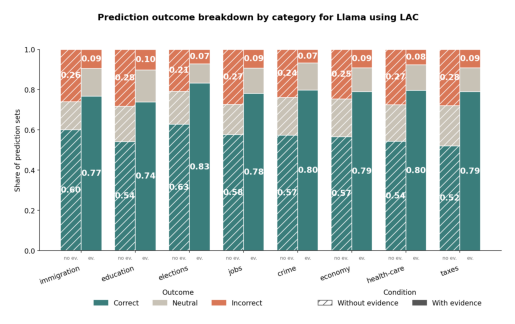

In [16]:
# Display the stacked bar

import matplotlib.pyplot as plt
img = plt.imread("visualisations_LAC/stacked_bar_lac.png")
plt.imshow(img); plt.axis("off"); plt.show()


# Conclusion from the first analysis:

### Without evidence, 21 to 28% of prediction sets lean toward the wrong truth side despite the 90% conformal coverage guarantee. With evidence, this drops to under 10% across all categories. This means that while conformal prediction ensures the true label is included in the set with high probability, the composition of the set without evidence is often misleading. A human fact-checker relying on the set's overall lean to guide a decision would be pointed in the wrong direction roughly a quarter of the time. Evidence reshapes the internal structure of the sets, not just their size, pushing them to concentrate on the correct side of the true/false boundary.

### It's also worth noting what happens to the neutral sets. Without evidence, around 14–20% of prediction sets are evenly split between the true and false sides, offering no directional signal at all. With evidence, this drops to roughly 10–16%, meaning fewer sets are ambiguous. Taken together, the share of sets that give a useful directional signal, leaning to the correct side, rises from roughly 52–63% without evidence to 74–83% with evidence, depending on the category.

# Second analysis: What are the distribution for each of the prediction set size (e.g., 1,2,3,4,5,6)?
### For each category, we will see the distribution of each prediction set sizes (how many are of size 1, 2, 3, 4, 5 and 6)

While not visible in the chart, the elections and immigration have 39 and 5 6-label prediction sets, and the rest have 0.

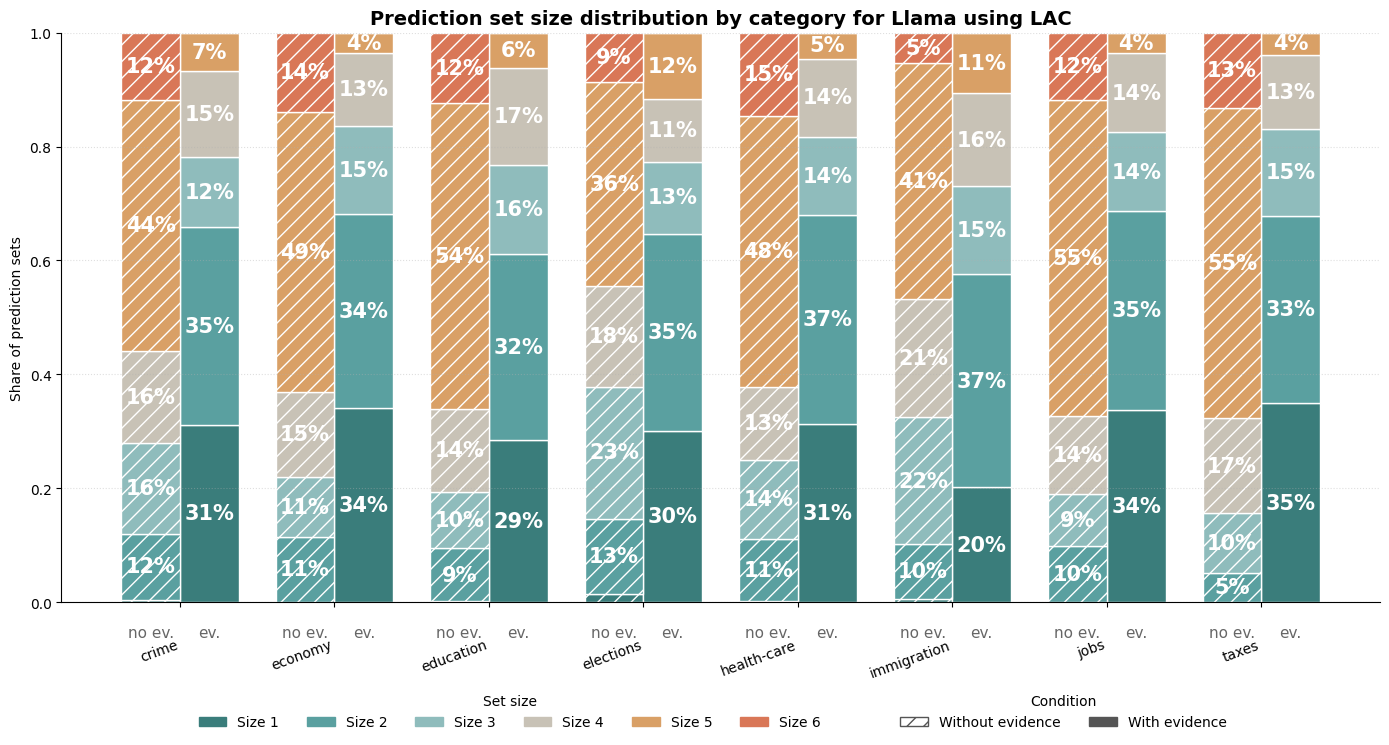

Saved: visualisations_LAC/set_size_distribution_lac.png


In [5]:
import os
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def parse_prediction_set(value):
    if isinstance(value, str):
        return ast.literal_eval(value)
    return value

def ensure_set_size(df):
    if "set_size" not in df.columns:
        df = df.copy()
        df["set_size"] = df["prediction_set"].apply(lambda x: len(parse_prediction_set(x)))
    return df

def get_size_percentages(csv_path):
    df = pd.read_csv(csv_path)
    df = ensure_set_size(df)
    counts = df["set_size"].value_counts().reindex([1, 2, 3, 4, 5, 6], fill_value=0)
    return counts / counts.sum()

def plot_all_categories_set_sizes(no_evidence_lac_llama_csv, with_evidence_lac_llama_csv, output_path="visualisations_LAC/set_size_distribution_lac.png"):
    categories = list(no_evidence_lac_llama_csv.keys())
    sizes = [1, 2, 3, 4, 5, 6]

    no_data = {cat: get_size_percentages(no_evidence_lac_llama_csv[cat]) for cat in categories}
    with_data = {cat: get_size_percentages(with_evidence_lac_llama_csv[cat]) for cat in categories}

    colors = ["#3a7d7b", "#5aa0a0", "#8fbcbc", "#c8c2b6", "#d9a066", "#d97757"]

    x = np.arange(len(categories))
    width = 0.38

    fig, ax = plt.subplots(figsize=(14, 8))

    for i, size in enumerate(sizes):
        no_bottom = np.array([sum(no_data[cat].iloc[:i]) for cat in categories])
        with_bottom = np.array([sum(with_data[cat].iloc[:i]) for cat in categories])

        no_vals = np.array([no_data[cat].iloc[i] for cat in categories])
        with_vals = np.array([with_data[cat].iloc[i] for cat in categories])

        ax.bar(
            x - width / 2,
            no_vals,
            width,
            bottom=no_bottom,
            color=colors[i],
            edgecolor="white",
            hatch="//",
        )
        ax.bar(
            x + width / 2,
            with_vals,
            width,
            bottom=with_bottom,
            color=colors[i],
            edgecolor="white",
        )

        for xi, bottom, val in zip(x - width / 2, no_bottom, no_vals):
            if val >= 0.04:
                ax.text(
                    xi,
                    bottom + val / 2,
                    f"{val:.0%}",
                    ha="center",
                    va="center",
                    fontsize=15,
                    color="white",
                    fontweight="bold",
                )

        for xi, bottom, val in zip(x + width / 2, with_bottom, with_vals):
            if val >= 0.01:
                ax.text(
                    xi,
                    bottom + val / 2,
                    f"{val:.0%}",
                    ha="center",
                    va="center",
                    fontsize=15,
                    color="white",
                    fontweight="bold",
                )

    for xi in x:
        ax.text(xi - width / 2, -0.04, "no ev.", ha="center", va="top", fontsize=11, color="#666")
        ax.text(xi + width / 2, -0.04, "ev.", ha="center", va="top", fontsize=11, color="#666")

    ax.set_xticks(x)
    ax.set_xticklabels(categories, rotation=20, ha="right")
    ax.tick_params(axis="x", pad=22)
    ax.set_ylim(0, 1)
    ax.set_ylabel("Share of prediction sets")
    ax.set_title("Prediction set size distribution by category for Llama using LAC", fontsize=14, fontweight="bold")
    ax.grid(axis="y", linestyle=":", alpha=0.4)

    condition_handles = [
        plt.Rectangle((0, 0), 1, 1, facecolor="white", edgecolor="#555", hatch="//", label="Without evidence"),
        plt.Rectangle((0, 0), 1, 1, facecolor="#555", edgecolor="#555", label="With evidence"),
    ]
    size_handles = [
        plt.Rectangle((0, 0), 1, 1, color=colors[i], label=f"Size {sizes[i]}")
        for i in range(len(sizes))
    ]

    leg1 = ax.legend(
        handles=size_handles,
        title="Set size",
        loc="upper center",
        bbox_to_anchor=(0.34, -0.14),
        ncol=6,
        frameon=False,
    )
    ax.add_artist(leg1)

    ax.legend(
        handles=condition_handles,
        title="Condition",
        loc="upper center",
        bbox_to_anchor=(0.76, -0.14),
        ncol=2,
        frameon=False,
    )

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.24)
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)

plot_all_categories_set_sizes(no_evidence_lac_llama_csv, with_evidence_lac_llama_csv, output_path="visualisations_LAC/set_size_distribution_lac.png")
print("Saved: visualisations_LAC/set_size_distribution_lac.png")

# Conclusion from the second analysis:

### Evidence makes prediction sets substantially smaller and more decisive. Without evidence, sets tend to spread across 4–6 labels, offering little practical guidance. With evidence, they concentrate heavily on sizes 1–2 across all categories, meaning the model commits to fewer labels with higher confidence. The effect is universal across topics, though some categories like education and health-care retain more residual uncertainty than others.

# Third analysis: What were the true label of the statements whose prediction set did not include it?

### Look for each of the failed prediction sets what should have them include

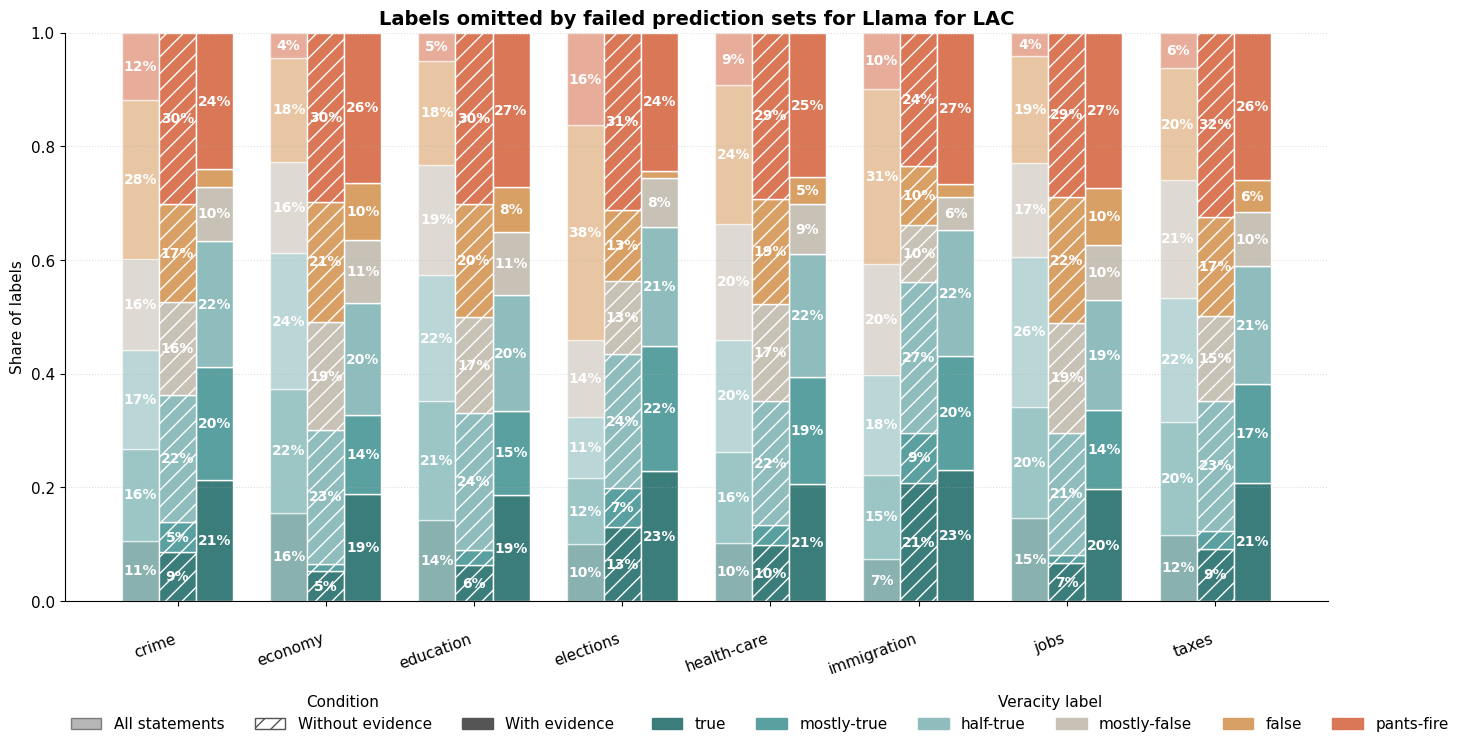

Saved: visualisations_LAC/failed_set_omissions_by_category.png


In [17]:
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

LABEL_ORDER = ["true", "mostly-true", "half-true", "mostly-false", "false", "pants-fire"]

def parse_prediction_set(value):
    if isinstance(value, str):
        return ast.literal_eval(value)
    return value

def get_failed_set_label_distribution(csv_path):
    df = pd.read_csv(csv_path)

    if "is_covered" not in df.columns:
        raise ValueError(f"{csv_path} does not contain an 'is_covered' column.")

    total_prediction_sets = len(df)
    failed_df = df[df["is_covered"] == False].copy()
    failed_df["prediction_set"] = failed_df["prediction_set"].apply(parse_prediction_set)

    omitted_counts = {label: 0 for label in LABEL_ORDER}
    total_omissions = 0

    for pred_set in failed_df["prediction_set"]:
        pred_set = set(pred_set)
        omitted_labels = [label for label in LABEL_ORDER if label not in pred_set]
        for label in omitted_labels:
            omitted_counts[label] += 1
            total_omissions += 1

    if total_omissions == 0:
        proportions = pd.Series({label: 0 for label in LABEL_ORDER})
    else:
        proportions = pd.Series(
            {label: omitted_counts[label] / total_omissions for label in LABEL_ORDER}
        )

    failed_rate = len(failed_df) / total_prediction_sets if total_prediction_sets else 0
    return proportions, len(failed_df), failed_rate

def get_all_statements_label_distribution(csv_path):
    df = pd.read_csv(csv_path)

    if "true_verdict" not in df.columns:
        raise ValueError(f"{csv_path} does not contain a 'true_verdict' column.")

    counts = df["true_verdict"].value_counts().reindex(LABEL_ORDER, fill_value=0)
    proportions = counts / counts.sum() if counts.sum() else counts
    return proportions, len(df)

def plot_failed_set_omissions(no_evidence_lac_llama_csv, with_evidence_lac_llama_csv, output_path="visualisations_LAC/failed_set_omissions_by_category.png"):
    categories = list(no_evidence_lac_llama_csv.keys())

    label_colors = {
        "true": "#3a7d7b",
        "mostly-true": "#5aa0a0",
        "half-true": "#8fbcbc",
        "mostly-false": "#c8c2b6",
        "false": "#d9a066",
        "pants-fire": "#d97757",
    }

    no_data = {}
    with_data = {}
    all_data = {}
    no_failed_rates = {}
    with_failed_rates = {}

    for category in categories:
        no_props, no_failed, no_failed_rate = get_failed_set_label_distribution(no_evidence_lac_llama_csv[category])
        with_props, with_failed, with_failed_rate = get_failed_set_label_distribution(with_evidence_lac_llama_csv[category])
        all_props, total_count = get_all_statements_label_distribution(no_evidence_lac_llama_csv[category])

        no_data[category] = no_props
        with_data[category] = with_props
        all_data[category] = all_props
        no_failed_rates[category] = no_failed_rate
        with_failed_rates[category] = with_failed_rate

    x = np.arange(len(categories))
    width = 0.25

    fig, ax = plt.subplots(figsize=(15, 8))

    no_bottom = np.zeros(len(categories))
    with_bottom = np.zeros(len(categories))
    all_bottom = np.zeros(len(categories))

    for label in LABEL_ORDER:
        no_vals = np.array([no_data[cat][label] for cat in categories])
        with_vals = np.array([with_data[cat][label] for cat in categories])
        all_vals = np.array([all_data[cat][label] for cat in categories])

        ax.bar(
            x - width,
            all_vals,
            width,
            bottom=all_bottom,
            color=label_colors[label],
            edgecolor="white",
            alpha=0.6,
        )
        ax.bar(
            x,
            no_vals,
            width,
            bottom=no_bottom,
            color=label_colors[label],
            edgecolor="white",
            hatch="//",
        )
        ax.bar(
            x + width,
            with_vals,
            width,
            bottom=with_bottom,
            color=label_colors[label],
            edgecolor="white",
        )

        for xi, bottom, val in zip(x - width, all_bottom, all_vals):
            if val >= 0.04:
                ax.text(
                    xi,
                    bottom + val / 2,
                    f"{val:.0%}",
                    ha="center",
                    va="center",
                    fontsize=10,
                    color="white",
                    fontweight="bold",
                )

        for xi, bottom, val in zip(x, no_bottom, no_vals):
            if val >= 0.04:
                ax.text(
                    xi,
                    bottom + val / 2,
                    f"{val:.0%}",
                    ha="center",
                    va="center",
                    fontsize=10,
                    color="white",
                    fontweight="bold",
                )

        for xi, bottom, val in zip(x + width, with_bottom, with_vals):
            if val >= 0.04:
                ax.text(
                    xi,
                    bottom + val / 2,
                    f"{val:.0%}",
                    ha="center",
                    va="center",
                    fontsize=10,
                    color="white",
                    fontweight="bold",
                )

        all_bottom += all_vals
        no_bottom += no_vals
        with_bottom += with_vals

    ax.set_ylim(0, 1)
    ax.set_xticks(x)
    ax.set_xticklabels(categories, rotation=20, ha="right")
    ax.tick_params(axis="x", pad=18)
    ax.set_ylabel("Share of labels")
    ax.set_title("Labels omitted by failed prediction sets for Llama for LAC", fontsize=14, fontweight="bold")
    ax.grid(axis="y", linestyle=":", alpha=0.4)

    condition_handles = [
        plt.Rectangle((0, 0), 1, 1, facecolor="#999", edgecolor="#555", alpha=0.7, label="All statements"),
        plt.Rectangle((0, 0), 1, 1, facecolor="white", edgecolor="#555", hatch="//", label="Without evidence"),
        plt.Rectangle((0, 0), 1, 1, facecolor="#555", edgecolor="#555", label="With evidence"),
    ]
    label_handles = [
        plt.Rectangle((0, 0), 1, 1, color=label_colors[label], label=label)
        for label in LABEL_ORDER
    ]

    leg1 = ax.legend(
        handles=condition_handles,
        title="Condition",
        bbox_to_anchor=(0.22, -0.14),
        loc="upper center",
        ncol=3,
        frameon=False,
    )
    ax.add_artist(leg1)

    ax.legend(
        handles=label_handles,
        title="Veracity label",
        bbox_to_anchor=(0.78, -0.14),
        loc="upper center",
        ncol=6,
        frameon=False,
    )

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.24)
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)

plot_failed_set_omissions(no_evidence_lac_llama_csv, with_evidence_lac_llama_csv)
print("Saved: visualisations_LAC/failed_set_omissions_by_category.png")

# Conclusion from the third analysis:

 
An untrained reader of conformal prediction would expect that the proportions for evidence and no evidence would be similar, as adding the evidence would just decrease the prediction set, not the coverage chance for a particular statement. However, the data shows that the failure profile shifts substantially between the two conditions. This suggests that evidence does not uniformly tighten the prediction sets, but it reshapes which kinds of claims the model becomes confident about and which it continues to misjudge. This behaviour is consistent with how conformal prediction interacts with the underlying classifier. The marginal 90% coverage guarantee holds in aggregate, but conditional coverage across veracity labels can drift when the input distribution changes. Adding evidence effectively changes the input distribution, as the LLama model now reasons over claim-plus-context rather than the claim alone, and the nonconformity scores shift accordingly.
 

# Fourth Analysis: Show performance in terms of prediction sets for both evidence and non evidence

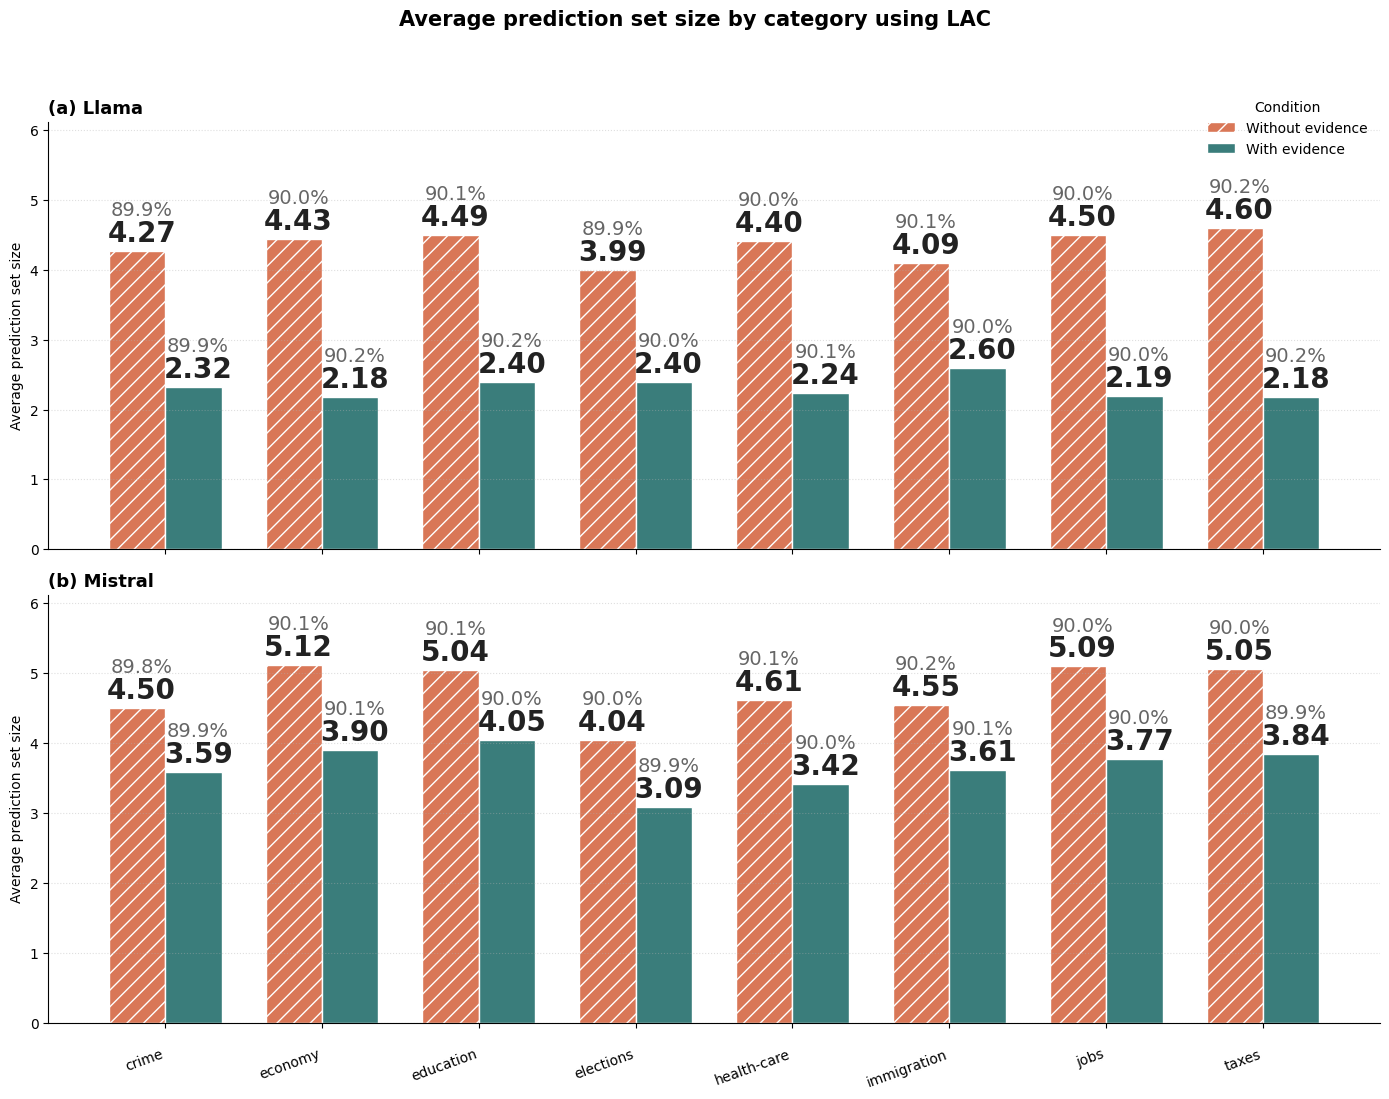

Saved: visualisations_LAC/average_prediction_set_sizes_llama.png


In [7]:
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

no_evidence_lac_mistral_csv = {
    'crime': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/mistral/zero-shot-lac/crime/conformal_results_all_trials_100trials_20260412_170140.csv",
    'economy': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/mistral/zero-shot-lac/economy/conformal_results_all_trials_100trials_20260412_235417.csv",
    'education': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/mistral/zero-shot-lac/education/conformal_results_all_trials_100trials_20260412_172745.csv",
    'elections': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/mistral/zero-shot-lac/elections/conformal_results_all_trials_100trials_20260412_234002.csv",
    'health-care': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/mistral/zero-shot-lac/health-care/conformal_results_all_trials_100trials_20260413_030310.csv",
    'immigration': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/mistral/zero-shot-lac/immigration/conformal_results_all_trials_100trials_20260413_020109.csv",
    'jobs': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/mistral/zero-shot-lac/jobs/conformal_results_all_trials_100trials_20260413_020352.csv",
    'taxes': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/mistral/zero-shot-lac/taxes/conformal_results_all_trials_100trials_20260413_030120.csv"
}

with_evidence_lac_mistral_csv = {
    'crime': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/mistral/zero-shot-lac-evidence/crime/conformal_results_all_trials_100trials_20260414_154947.csv",
    'economy': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/mistral/zero-shot-lac-evidence/economy/conformal_results_all_trials_100trials_20260426_003936.csv",
    'education': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/mistral/zero-shot-lac-evidence/education/conformal_results_all_trials_100trials_20260414_173101.csv",
    'elections': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/mistral/zero-shot-lac-evidence/elections/conformal_results_all_trials_100trials_20260415_041233.csv",
    'health-care': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/mistral/zero-shot-lac-evidence/health-care/conformal_results_all_trials_100trials_20260503_192034.csv",
    'immigration': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/mistral/zero-shot-lac-evidence/immigration/conformal_results_all_trials_100trials_20260427_085329.csv",
    'jobs': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/mistral/zero-shot-lac-evidence/jobs/conformal_results_all_trials_100trials_20260427_070511.csv",
    'taxes': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/mistral/zero-shot-lac-evidence/taxes/conformal_results_all_trials_100trials_20260427_105625.csv"
}


def parse_prediction_set(value):
    if isinstance(value, str):
        return ast.literal_eval(value)
    return value


def ensure_set_size(df):
    if "set_size" not in df.columns:
        df = df.copy()
        df["set_size"] = df["prediction_set"].apply(lambda x: len(parse_prediction_set(x)))
    return df


def get_average_metrics(csv_path):
    df = pd.read_csv(csv_path)
    df = ensure_set_size(df)
    avg_set_size = df["set_size"].mean()
    avg_coverage = df["is_covered"].mean()  # <-- change column name if yours differs
    return avg_set_size, avg_coverage


def _plot_model_panel(ax, categories, no_sizes, with_sizes, no_covs, with_covs,
                      title, show_legend, show_xticklabels):
    x = np.arange(len(categories))
    width = 0.36

    ax.bar(
        x - width / 2,
        no_sizes,
        width,
        label="Without evidence",
        color="#d97757",
        edgecolor="white",
        hatch="//",
    )
    ax.bar(
        x + width / 2,
        with_sizes,
        width,
        label="With evidence",
        color="#3a7d7b",
        edgecolor="white",
    )

    def annotate(xi, size_val, cov_val):
        ax.text(xi + 0.03, size_val + 0.05, f"{size_val:.2f}",
                ha="center", va="bottom", fontsize=20, fontweight="bold", color="#222")
        ax.text(xi + 0.03, size_val + 0.45, f"{cov_val * 100:.1f}%",
                ha="center", va="bottom", fontsize=14, color="#666")

    for xi, s, c in zip(x - width / 2, no_sizes, no_covs):
        annotate(xi, s, c)
    for xi, s, c in zip(x + width / 2, with_sizes, with_covs):
        annotate(xi, s, c)

    ax.set_xticks(x)
    if show_xticklabels:
        ax.set_xticklabels(categories, rotation=20, ha="right")
        ax.tick_params(axis="x", pad=14)
    else:
        ax.set_xticklabels([])

    ax.set_ylabel("Average prediction set size")
    ax.set_title(title, fontsize=13, fontweight="bold", loc="left")
    ax.grid(axis="y", linestyle=":", alpha=0.4)

    if show_legend:
        ax.legend(title="Condition", frameon=False,
                loc="upper right", bbox_to_anchor=(1.0, 1.08))


def plot_average_prediction_set_sizes(
    no_evidence_lac_llama_csv,
    with_evidence_lac_llama_csv,
    no_evidence_lac_mistral_csv,
    with_evidence_lac_mistral_csv,
    output_path="visualisations_LAC/average_prediction_set_sizes_llama.png",
):
    categories = list(no_evidence_lac_llama_csv.keys())

    def gather(csv_dict):
        sizes, covs = [], []
        for c in categories:
            s, cov = get_average_metrics(csv_dict[c])
            sizes.append(s)
            covs.append(cov)
        return np.array(sizes), np.array(covs)

    llama_no_s, llama_no_c = gather(no_evidence_lac_llama_csv)
    llama_w_s, llama_w_c = gather(with_evidence_lac_llama_csv)
    mist_no_s, mist_no_c = gather(no_evidence_lac_mistral_csv)
    mist_w_s, mist_w_c = gather(with_evidence_lac_mistral_csv)

    # Shared y-limit so the two panels are directly comparable
    # Extra headroom (+1.0) so the stacked size + coverage labels don't get clipped
    y_max = max(llama_no_s.max(), llama_w_s.max(),
                mist_no_s.max(), mist_w_s.max()) + 1.0

    fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(14, 11), sharex=True)

    _plot_model_panel(ax_top, categories, llama_no_s, llama_w_s, llama_no_c, llama_w_c,
                      title="(a) Llama", show_legend=True, show_xticklabels=False)
    _plot_model_panel(ax_bot, categories, mist_no_s, mist_w_s, mist_no_c, mist_w_c,
                      title="(b) Mistral", show_legend=False, show_xticklabels=True)

    ax_top.set_ylim(0, y_max)
    ax_bot.set_ylim(0, y_max)

    fig.suptitle(
        "Average prediction set size by category using LAC",
        fontsize=15, fontweight="bold", y=0.995,
    )

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)


plot_average_prediction_set_sizes(
    no_evidence_lac_llama_csv,
    with_evidence_lac_llama_csv,
    no_evidence_lac_mistral_csv,
    with_evidence_lac_mistral_csv,
)
print("Saved: visualisations_LAC/average_prediction_set_sizes_llama.png")

# Fifth analysis: Show the spread of LAC

### Prediction set such as ['true', 'false'] are not helpful, and while the size is 2, the actual sprea is ['true', 'mostly-true', 'half-true', 'mostly-false', 'false'] while has size 5.

Here, we calculate the real spread for both Llama and Mistral


Llama - no evidence
   category mean_spread median_spread pct_spread_ge_4
      crime        4.41           5.0           73.6%
    economy        4.52           5.0           79.8%
  education        4.59           5.0           82.6%
  elections        4.18           5.0           66.9%
health-care        4.50           5.0           76.9%
immigration        4.27           5.0           71.6%
       jobs        4.58           5.0           82.8%
      taxes        4.72           5.0           86.7%

Llama - with evidence
   category mean_spread median_spread pct_spread_ge_4
      crime        2.37           2.0           24.2%
    economy        2.23           2.0           19.0%
  education        2.50           2.0           27.6%
  elections        2.44           2.0           24.3%
health-care        2.29           2.0           20.5%
immigration        2.65           2.0           29.7%
       jobs        2.23           2.0           19.8%
      taxes        2.24           2.0 

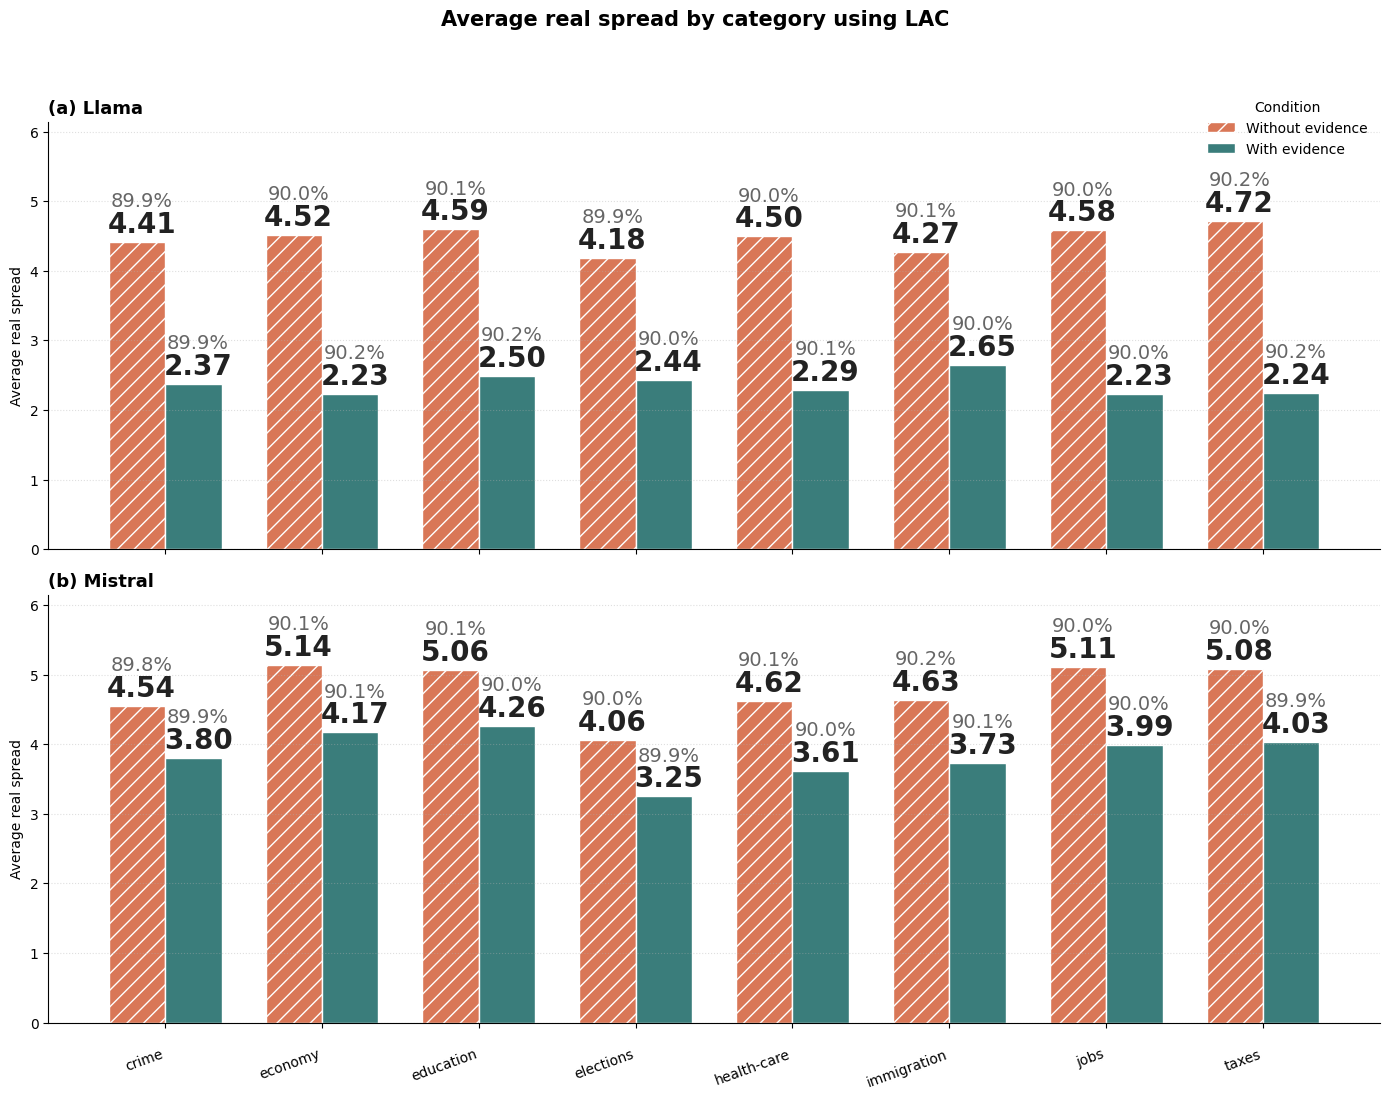

In [8]:
import ast
import pandas as pd
import numpy as np

LABEL_ORDER = ["true", "mostly-true", "half-true", "mostly-false", "false", "pants-fire"]
LABEL_TO_INDEX = {label: i for i, label in enumerate(LABEL_ORDER)}

def parse_prediction_set(value):
    if isinstance(value, str):
        return ast.literal_eval(value)
    return value

def real_spread(prediction_set):
    labels = parse_prediction_set(prediction_set)
    indices = [LABEL_TO_INDEX[l] for l in labels if l in LABEL_TO_INDEX]
    if not indices:
        return np.nan
    return (max(indices) - min(indices)) + 1  # inclusive span length

def add_spread(df):
    df = df.copy()
    df["real_spread"] = df["prediction_set"].apply(real_spread)
    return df

def summarize_spread(csv_dict, name):
    rows = []
    for cat, path in csv_dict.items():
        df = pd.read_csv(path)
        df = add_spread(df)
        rows.append({
            "category": cat,
            "mean_spread": df["real_spread"].mean(),
            "median_spread": df["real_spread"].median(),
            "pct_spread_ge_4": (df["real_spread"] >= 4).mean(),
        })
    out = pd.DataFrame(rows).sort_values("category")
    print(f"\n{name}")
    print(out.to_string(index=False, formatters={
        "mean_spread": "{:.2f}".format,
        "median_spread": "{:.1f}".format,
        "pct_spread_ge_4": "{:.1%}".format,
    }))
    return out

# Llama
summarize_spread(no_evidence_lac_llama_csv, "Llama - no evidence")
summarize_spread(with_evidence_lac_llama_csv, "Llama - with evidence")

# Mistral
summarize_spread(no_evidence_lac_mistral_csv, "Mistral - no evidence")
summarize_spread(with_evidence_lac_mistral_csv, "Mistral - with evidence")


import matplotlib.pyplot as plt

def spread_and_coverage(csv_dict):
    rows = []
    for cat, path in csv_dict.items():
        df = pd.read_csv(path)
        df = add_spread(df)
        rows.append({
            "category": cat,
            "mean_spread": df["real_spread"].mean(),
            "coverage": df["is_covered"].mean(),
        })
    out = pd.DataFrame(rows).sort_values("category")
    return out

def _plot_spread_panel(ax, categories, no_spread, with_spread, no_cov, with_cov,
                       title, show_legend, show_xticklabels):
    x = np.arange(len(categories))
    width = 0.36

    ax.bar(
        x - width / 2,
        no_spread,
        width,
        label="Without evidence",
        color="#d97757",
        edgecolor="white",
        hatch="//",
    )
    ax.bar(
        x + width / 2,
        with_spread,
        width,
        label="With evidence",
        color="#3a7d7b",
        edgecolor="white",
    )

    def annotate(xi, spread_val, cov_val):
        ax.text(
            xi + 0.03,
            spread_val + 0.05,
            f"{spread_val:.2f}",
            ha="center",
            va="bottom",
            fontsize=20,
            fontweight="bold",
            color="#222",
        )
        ax.text(
            xi + 0.03,
            spread_val + 0.45,
            f"{cov_val * 100:.1f}%",
            ha="center",
            va="bottom",
            fontsize=14,
            color="#666",
        )

    for xi, s, c in zip(x - width / 2, no_spread, no_cov):
        annotate(xi, s, c)
    for xi, s, c in zip(x + width / 2, with_spread, with_cov):
        annotate(xi, s, c)

    ax.set_xticks(x)
    if show_xticklabels:
        ax.set_xticklabels(categories, rotation=20, ha="right")
        ax.tick_params(axis="x", pad=14)
    else:
        ax.set_xticklabels([])

    ax.set_ylabel("Average real spread")
    ax.set_title(title, fontsize=13, fontweight="bold", loc="left")
    ax.grid(axis="y", linestyle=":", alpha=0.4)

    if show_legend:
        ax.legend(title="Condition", frameon=False,
                  loc="upper right", bbox_to_anchor=(1.0, 1.08))

def plot_real_spread_by_category(
    no_evidence_lac_llama_csv,
    with_evidence_lac_llama_csv,
    no_evidence_lac_mistral_csv,
    with_evidence_lac_mistral_csv,
    output_path="visualisations_LAC/real_spread_by_category_LAC.png",
):
    llama_no = spread_and_coverage(no_evidence_lac_llama_csv)
    llama_w  = spread_and_coverage(with_evidence_lac_llama_csv)
    mist_no  = spread_and_coverage(no_evidence_lac_mistral_csv)
    mist_w   = spread_and_coverage(with_evidence_lac_mistral_csv)

    categories = llama_no["category"].tolist()

    llama_no_s = llama_no["mean_spread"].values
    llama_w_s  = llama_w["mean_spread"].values
    mist_no_s  = mist_no["mean_spread"].values
    mist_w_s   = mist_w["mean_spread"].values

    llama_no_c = llama_no["coverage"].values
    llama_w_c  = llama_w["coverage"].values
    mist_no_c  = mist_no["coverage"].values
    mist_w_c   = mist_w["coverage"].values

    y_max = max(llama_no_s.max(), llama_w_s.max(), mist_no_s.max(), mist_w_s.max()) + 1.0

    fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(14, 11), sharex=True)

    _plot_spread_panel(
        ax_top, categories,
        llama_no_s, llama_w_s, llama_no_c, llama_w_c,
        title="(a) Llama", show_legend=True, show_xticklabels=False
    )
    _plot_spread_panel(
        ax_bot, categories,
        mist_no_s, mist_w_s, mist_no_c, mist_w_c,
        title="(b) Mistral", show_legend=False, show_xticklabels=True
    )

    ax_top.set_ylim(0, y_max)
    ax_bot.set_ylim(0, y_max)

    fig.suptitle(
        "Average real spread by category using LAC",
        fontsize=15, fontweight="bold", y=0.995,
    )

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)

plot_real_spread_by_category(
    no_evidence_lac_llama_csv,
    with_evidence_lac_llama_csv,
    no_evidence_lac_mistral_csv,
    with_evidence_lac_mistral_csv,
)

# Sixth evaluation: Check if the coverage changes for statements made before and after the cut-off period

In [9]:
# Give me the set of statements where the Llama model with evidence gave a prediction set of size 5 for the crime category. Also look at the crime dataset found here: datasets\politifact-crime.json and give me the year and author for each of those statements.

import json
import re
import unicodedata
import pandas as pd

csv_path = r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/llama/zero-shot-lac-evidence/crime/conformal_results_all_trials_100trials_20260407_071658.csv"
json_path = r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/datasets/politifact-crime.json"

def normalize_statement(s):
    s = str(s).strip()
    s = unicodedata.normalize("NFKD", s)
    s = s.translate({
        ord("“"): '"', ord("”"): '"',
        ord("‘"): "'", ord("’"): "'",
    })
    s = re.sub(r"\s+", " ", s)
    return s.casefold()

# Results CSV (with evidence)
df = pd.read_csv(csv_path)
df5 = df[df["set_size"] == 5].copy()
df5["statement_norm"] = df5["statement"].map(normalize_statement)

# Crime dataset
with open(json_path, "r", encoding="utf-8") as f:
    crime_data = json.load(f)

crime_df = pd.DataFrame(crime_data)
crime_df["statement_norm"] = crime_df["statement"].map(normalize_statement)

# Join and extract year + author
merged = df5.merge(crime_df, on="statement_norm", how="left", suffixes=("_pred", "_crime"))
merged["year"] = merged["statement_date"].str.extract(r"(\d{4})")
merged["author"] = merged["statement_originator"]

result = merged[["statement_pred", "year", "author"]].rename(
    columns={"statement_pred": "statement"}
)

result = result.drop_duplicates(subset=["statement"], keep="first")

result = result.sort_values(
    by=["year", "statement"],
    key=lambda s: pd.to_numeric(s, errors="coerce"),
    ascending=False
).reset_index(drop=True)
# print(result.to_string(index=False))

# Optional: see statements that failed to match the dataset
missing = merged[merged["author"].isna()][["statement_pred"]]
if not missing.empty:
    print("\nUnmatched statements:")
    print(missing.to_string(index=False))


# Now for each year print the number of statements with size 5 prediction sets

size5_counts = result.groupby("year").size().reset_index(name="size_5_count")
print(size5_counts.to_string(index=False))




year  size_5_count
2010             1
2011             5
2012            13
2013            20
2014            20
2015            11
2016            14
2017            11
2018             7
2019             6
2020             6
2021             2
2022             4
2024             2
2025             2


OVERALL METRICS (all categories combined)
                    No Evidence  With Evidence
Mean set size          4.344281       2.303554
Median set size        5.000000       2.000000
Coverage rate          0.900204       0.900854
Accuracy               0.292249       0.610956
Unique statements  10877.000000   10872.000000

SET SIZE DISTRIBUTION (% of predictions)
          No Evidence (%)  With Evidence (%)
Set Size                                    
1                     0.4               30.7
2                    10.2               34.7
3                    14.6               14.3
4                    15.8               13.8
5                    47.3                6.4
6                    11.7                0.0


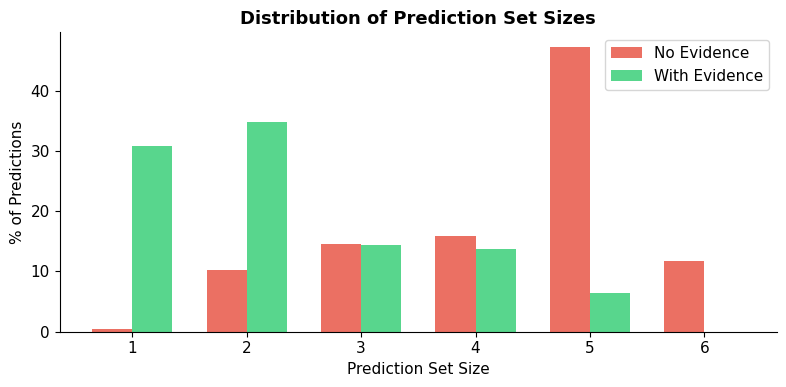


METRICS BY TRUE VERDICT LABEL
              Set Size (no ev.)  Set Size (with ev.)  Coverage (no ev.)  Coverage (with ev.)  Accuracy (no ev.)  Accuracy (with ev.)
True Label                                                                                                                          
true                      4.205                2.014              0.957                0.941              0.244                0.744
mostly-true               4.295                2.468              0.985                0.959              0.661                0.677
half-true                 4.538                2.609              0.808                0.832              0.000                0.360
mostly-false              4.586                2.760              0.924                0.950              0.037                0.453
false                     4.237                1.934              0.934                0.989              0.561                0.895
pants-fire                3.997       

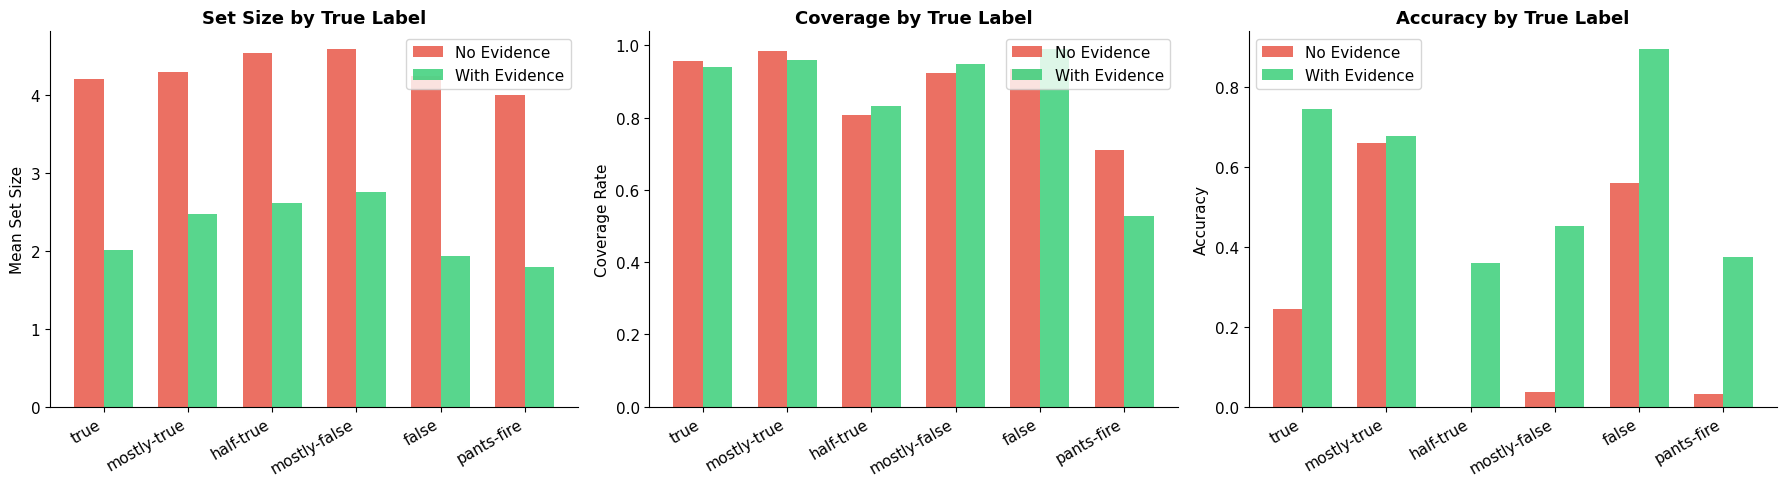


METRICS BY CATEGORY
             Set Size (no ev.)  Set Size (with ev.)  Δ Set Size  Coverage (no ev.)  Coverage (with ev.)  Accuracy (no ev.)  Accuracy (with ev.)
Category                                                                                                                                       
crime                    4.273                2.317       1.956              0.899                0.899              0.312                0.591
economy                  4.435                2.178       2.257              0.900                0.902              0.268                0.629
education                4.494                2.398       2.096              0.901                0.902              0.254                0.596
elections                3.993                2.396       1.597              0.899                0.900              0.381                0.632
health-care              4.405                2.236       2.169              0.900                0.901            

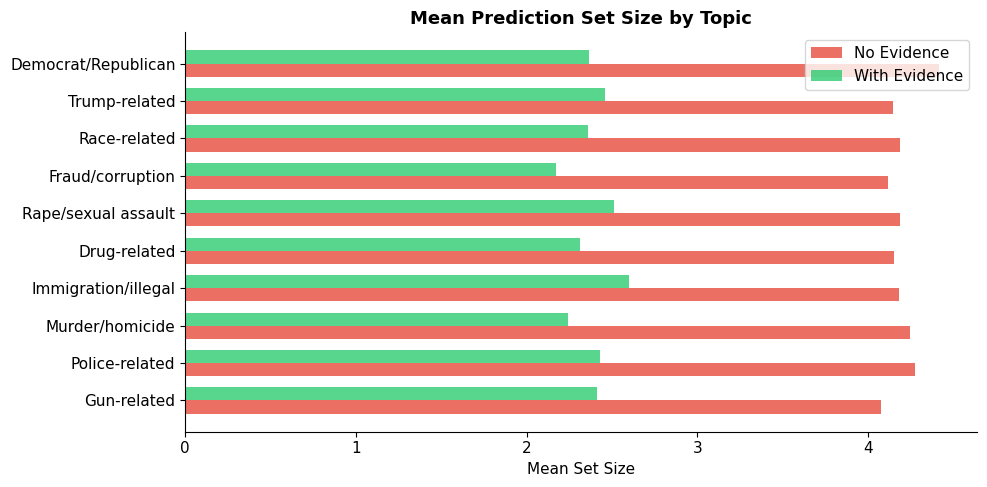


TOP 15 STATEMENTS WHERE EVIDENCE HELPED MOST (reduced set size)
  [   half-true] Δ=+5.00  (no_ev=6.00 → ev=1.00)  "99.97 percent of the kids live in poverty that attend Cleveland public schools."
  [   half-true] Δ=+5.00  (no_ev=6.00 → ev=1.00)  "A lot of people don't know that 50,000 Americans now make their living off eBay."
  [        true] Δ=+5.00  (no_ev=6.00 → ev=1.00)  "And, as of today, New Jersey state government has less employees than when Christie Whitm
  [   half-true] Δ=+5.00  (no_ev=6.00 → ev=1.00)  "Any government-run 'public' plan ... creates an entitlement that will cost another $1 tri
  [   half-true] Δ=+5.00  (no_ev=6.00 → ev=1.00)  "As governor, Mike Huckabee supported higher income taxes, sales taxes, gas taxes, grocery
  [mostly-false] Δ=+5.00  (no_ev=6.00 → ev=1.00)  "Barack Obama and Hillary Clinton have left us with $19 trillion in debt."
  [   half-true] Δ=+5.00  (no_ev=6.00 → ev=1.00)  "Both the state and federal governments make more per gallon in gas taxe

In [10]:
import pandas as pd
import numpy as np
import ast
import re
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({'font.size': 11})

# ── 1. Load & combine all categories ──────────────────────────────────────────

no_evidence_csv = {
    'crime': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/llama/zero-shot-lac/crime/conformal_results_all_trials_100trials_20260327_141313.csv",
    'economy': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/llama/zero-shot-lac/economy/conformal_results_all_trials_100trials_20260327_153533.csv",
    'education': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/llama/zero-shot-lac/education/conformal_results_all_trials_100trials_20260327_143823.csv",
    'elections': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/llama/zero-shot-lac/elections/conformal_results_all_trials_100trials_20260327_153731.csv",
    'health-care': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/llama/zero-shot-lac/health-care/conformal_results_all_trials_100trials_20260327_155654.csv",
    'immigration': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/llama/zero-shot-lac/immigration/conformal_results_all_trials_100trials_20260327_144131.csv",
    'jobs': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/llama/zero-shot-lac/jobs/conformal_results_all_trials_100trials_20260327_142840.csv",
    'taxes': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/llama/zero-shot-lac/taxes/conformal_results_all_trials_100trials_20260327_151637.csv"
}

with_evidence_csv = {
    'crime': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/llama/zero-shot-lac-evidence/crime/conformal_results_all_trials_100trials_20260407_071658.csv",
    'economy': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/llama/zero-shot-lac-evidence/economy/conformal_results_all_trials_100trials_20260407_140549.csv",
    'education': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/llama/zero-shot-lac-evidence/education/conformal_results_all_trials_100trials_20260407_102821.csv",
    'elections': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/llama/zero-shot-lac-evidence/elections/conformal_results_all_trials_100trials_20260407_134947.csv",
    'health-care': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/llama/zero-shot-lac-evidence/health-care/conformal_results_all_trials_100trials_20260407_163030.csv",
    'immigration': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/llama/zero-shot-lac-evidence/immigration/conformal_results_all_trials_100trials_20260407_102713.csv",
    'jobs': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/llama/zero-shot-lac-evidence/jobs/conformal_results_all_trials_100trials_20260407_084803.csv",
    'taxes': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/llama/zero-shot-lac-evidence/taxes/conformal_results_all_trials_100trials_20260407_122809.csv"
}

frames_no_ev, frames_ev = [], []
for cat in no_evidence_csv:
    df = pd.read_csv(no_evidence_csv[cat])
    df['category'] = cat
    frames_no_ev.append(df)
    df2 = pd.read_csv(with_evidence_csv[cat])
    df2['category'] = cat
    frames_ev.append(df2)

df_no = pd.concat(frames_no_ev, ignore_index=True)
df_ev = pd.concat(frames_ev, ignore_index=True)

df_no['is_correct'] = df_no['predicted_verdict'] == df_no['true_verdict']
df_ev['is_correct'] = df_ev['predicted_verdict'] == df_ev['true_verdict']

# ── 2. Overall metrics ───────────────────────────────────────────────────────

print("=" * 70)
print("OVERALL METRICS (all categories combined)")
print("=" * 70)
metrics = pd.DataFrame({
    'No Evidence': [
        df_no['set_size'].mean(),
        df_no['set_size'].median(),
        df_no['is_covered'].mean(),
        df_no['is_correct'].mean(),
        len(df_no['statement'].unique()),
    ],
    'With Evidence': [
        df_ev['set_size'].mean(),
        df_ev['set_size'].median(),
        df_ev['is_covered'].mean(),
        df_ev['is_correct'].mean(),
        len(df_ev['statement'].unique()),
    ]
}, index=['Mean set size', 'Median set size', 'Coverage rate', 'Accuracy', 'Unique statements'])
print(metrics.to_string())

# ── 3. Set size distribution ─────────────────────────────────────────────────

print("\n" + "=" * 70)
print("SET SIZE DISTRIBUTION (% of predictions)")
print("=" * 70)
dist_no = df_no['set_size'].value_counts(normalize=True).sort_index() * 100
dist_ev = df_ev['set_size'].value_counts(normalize=True).sort_index() * 100
dist_df = pd.DataFrame({'No Evidence (%)': dist_no, 'With Evidence (%)': dist_ev}).fillna(0)
dist_df.index.name = 'Set Size'
print(dist_df.round(1).to_string())

# Plot set size distribution
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
x = np.arange(len(dist_df))
w = 0.35
ax.bar(x - w/2, dist_df['No Evidence (%)'], w, label='No Evidence', color='#e74c3c', alpha=0.8)
ax.bar(x + w/2, dist_df['With Evidence (%)'], w, label='With Evidence', color='#2ecc71', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(dist_df.index)
ax.set_xlabel('Prediction Set Size')
ax.set_ylabel('% of Predictions')
ax.set_title('Distribution of Prediction Set Sizes')
ax.legend()
plt.tight_layout()
plt.show()

# ── 4. Breakdown by true verdict label ───────────────────────────────────────

print("\n" + "=" * 70)
print("METRICS BY TRUE VERDICT LABEL")
print("=" * 70)
label_order = ['true', 'mostly-true', 'half-true', 'mostly-false', 'false', 'pants-fire']

rows = []
for label in label_order:
    sub_no = df_no[df_no['true_verdict'] == label]
    sub_ev = df_ev[df_ev['true_verdict'] == label]
    rows.append({
        'True Label': label,
        'Set Size (no ev.)': sub_no['set_size'].mean(),
        'Set Size (with ev.)': sub_ev['set_size'].mean(),
        'Coverage (no ev.)': sub_no['is_covered'].mean(),
        'Coverage (with ev.)': sub_ev['is_covered'].mean(),
        'Accuracy (no ev.)': sub_no['is_correct'].mean(),
        'Accuracy (with ev.)': sub_ev['is_correct'].mean(),
    })
label_df = pd.DataFrame(rows).set_index('True Label')
print(label_df.round(3).to_string())

# Plot per-label set size comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
x = np.arange(len(label_order))
w = 0.35

axes[0].bar(x - w/2, label_df['Set Size (no ev.)'], w, label='No Evidence', color='#e74c3c', alpha=0.8)
axes[0].bar(x + w/2, label_df['Set Size (with ev.)'], w, label='With Evidence', color='#2ecc71', alpha=0.8)
axes[0].set_xticks(x); axes[0].set_xticklabels(label_order, rotation=30, ha='right')
axes[0].set_ylabel('Mean Set Size'); axes[0].set_title('Set Size by True Label'); axes[0].legend()

axes[1].bar(x - w/2, label_df['Coverage (no ev.)'], w, label='No Evidence', color='#e74c3c', alpha=0.8)
axes[1].bar(x + w/2, label_df['Coverage (with ev.)'], w, label='With Evidence', color='#2ecc71', alpha=0.8)
axes[1].set_xticks(x); axes[1].set_xticklabels(label_order, rotation=30, ha='right')
axes[1].set_ylabel('Coverage Rate'); axes[1].set_title('Coverage by True Label'); axes[1].legend()

axes[2].bar(x - w/2, label_df['Accuracy (no ev.)'], w, label='No Evidence', color='#e74c3c', alpha=0.8)
axes[2].bar(x + w/2, label_df['Accuracy (with ev.)'], w, label='With Evidence', color='#2ecc71', alpha=0.8)
axes[2].set_xticks(x); axes[2].set_xticklabels(label_order, rotation=30, ha='right')
axes[2].set_ylabel('Accuracy'); axes[2].set_title('Accuracy by True Label'); axes[2].legend()

plt.tight_layout()
plt.show()

# ── 5. Per-category comparison ────────────────────────────────────────────────

print("\n" + "=" * 70)
print("METRICS BY CATEGORY")
print("=" * 70)
cat_rows = []
for cat in sorted(no_evidence_csv.keys()):
    sub_no = df_no[df_no['category'] == cat]
    sub_ev = df_ev[df_ev['category'] == cat]
    cat_rows.append({
        'Category': cat,
        'Set Size (no ev.)': sub_no['set_size'].mean(),
        'Set Size (with ev.)': sub_ev['set_size'].mean(),
        'Δ Set Size': sub_no['set_size'].mean() - sub_ev['set_size'].mean(),
        'Coverage (no ev.)': sub_no['is_covered'].mean(),
        'Coverage (with ev.)': sub_ev['is_covered'].mean(),
        'Accuracy (no ev.)': sub_no['is_correct'].mean(),
        'Accuracy (with ev.)': sub_ev['is_correct'].mean(),
    })
cat_df = pd.DataFrame(cat_rows).set_index('Category')
print(cat_df.round(3).to_string())

# ── 6. Topic / theme-based patterns ──────────────────────────────────────────

print("\n" + "=" * 70)
print("MEAN SET SIZE BY STATEMENT TOPIC / THEME")
print("=" * 70)

themes = {
    'Gun-related': r'\bgun|firearm|shoot|second amendment|nra|bump stock|concealed.carry\b',
    'Police-related': r'\bpolice|officer|sheriff|law enforcement|cop\b',
    'Murder/homicide': r'\bmurder|homicide|kill|slay|deadly\b',
    'Immigration/illegal': r'\bimmigra|illegal alien|undocumented|border|deport|sanctuary\b',
    'Drug-related': r'\bdrug|heroin|opioid|marijuana|meth|narcotic\b',
    'Rape/sexual assault': r'\brape|sexual assault|sex offend|trafficking|molest\b',
    'Fraud/corruption': r'\bfraud|corrupt|scandal|bribe|extort|swindle\b',
    'Race-related': r'\bblack|african.american|white|racial|race|hate crime\b',
    'Trump-related': r'\btrump\b',
    'Democrat/Republican': r'\bdemocrat|republican|gop|dnc|rnc\b',
}

theme_rows = []
for theme, pattern in themes.items():
    mask_no = df_no['statement'].str.contains(pattern, case=False, regex=True, na=False)
    mask_ev = df_ev['statement'].str.contains(pattern, case=False, regex=True, na=False)
    if mask_no.sum() > 0 and mask_ev.sum() > 0:
        theme_rows.append({
            'Theme': theme,
            'Set Size (no ev.)': df_no.loc[mask_no, 'set_size'].mean(),
            'Set Size (with ev.)': df_ev.loc[mask_ev, 'set_size'].mean(),
            'Δ Set Size': df_no.loc[mask_no, 'set_size'].mean() - df_ev.loc[mask_ev, 'set_size'].mean(),
            'N statements (no ev.)': mask_no.sum(),
            'N statements (with ev.)': mask_ev.sum(),
        })
theme_df = pd.DataFrame(theme_rows).set_index('Theme')
print(theme_df.round(3).to_string())

# Plot theme comparison
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(theme_df))
w = 0.35
ax.barh(x - w/2, theme_df['Set Size (no ev.)'], w, label='No Evidence', color='#e74c3c', alpha=0.8)
ax.barh(x + w/2, theme_df['Set Size (with ev.)'], w, label='With Evidence', color='#2ecc71', alpha=0.8)
ax.set_yticks(x)
ax.set_yticklabels(theme_df.index)
ax.set_xlabel('Mean Set Size')
ax.set_title('Mean Prediction Set Size by Topic')
ax.legend()
plt.tight_layout()
plt.show()

# ── 7. Statements where evidence helped / hurt the most ──────────────────────

print("\n" + "=" * 70)
print("TOP 15 STATEMENTS WHERE EVIDENCE HELPED MOST (reduced set size)")
print("=" * 70)

avg_no = df_no.groupby('statement').agg(
    avg_set_no=('set_size', 'mean'),
    true_verdict=('true_verdict', 'first')
).reset_index()
avg_ev = df_ev.groupby('statement').agg(
    avg_set_ev=('set_size', 'mean'),
).reset_index()

merged = avg_no.merge(avg_ev, on='statement', how='inner')
merged['delta'] = merged['avg_set_no'] - merged['avg_set_ev']

helped = merged.nlargest(15, 'delta')
for _, row in helped.iterrows():
    print(f"  [{row['true_verdict']:>12}] Δ={row['delta']:+.2f}  "
          f"(no_ev={row['avg_set_no']:.2f} → ev={row['avg_set_ev']:.2f})  "
          f"{row['statement'][:90]}")

print("\n" + "=" * 70)
print("TOP 15 STATEMENTS WHERE EVIDENCE HURT MOST (increased set size)")
print("=" * 70)
hurt = merged.nsmallest(15, 'delta')
for _, row in hurt.iterrows():
    print(f"  [{row['true_verdict']:>12}] Δ={row['delta']:+.2f}  "
          f"(no_ev={row['avg_set_no']:.2f} → ev={row['avg_set_ev']:.2f})  "
          f"{row['statement'][:90]}")

# ── 8. Statements that are hard in BOTH conditions ───────────────────────────

print("\n" + "=" * 70)
print("STATEMENTS HARD TO CLASSIFY IN BOTH CONDITIONS (avg set_size >= 4)")
print("=" * 70)
hard = merged[(merged['avg_set_no'] >= 4) & (merged['avg_set_ev'] >= 4)]
print(f"Total: {len(hard)} statements\n")
print("Label distribution of hard statements:")
print(hard['true_verdict'].value_counts().to_string())
print()
for _, row in hard.head(20).iterrows():
    print(f"  [{row['true_verdict']:>12}]  no_ev={row['avg_set_no']:.1f}  ev={row['avg_set_ev']:.1f}  "
          f"{row['statement'][:85]}")

# ── 9. Summary statistics ────────────────────────────────────────────────────

print("\n" + "=" * 70)
print("KEY TAKEAWAYS")
print("=" * 70)
print(f"  • Evidence reduces mean set size by {df_no['set_size'].mean() - df_ev['set_size'].mean():.2f} "
      f"({df_no['set_size'].mean():.2f} → {df_ev['set_size'].mean():.2f})")
print(f"  • Coverage stays similar: {df_no['is_covered'].mean():.3f} → {df_ev['is_covered'].mean():.3f}")
print(f"  • Accuracy nearly doubles: {df_no['is_correct'].mean():.3f} → {df_ev['is_correct'].mean():.3f}")
pct_single_no = (df_no['set_size'] == 1).mean() * 100
pct_single_ev = (df_ev['set_size'] == 1).mean() * 100
print(f"  • Single-label predictions: {pct_single_no:.1f}% → {pct_single_ev:.1f}%")
print(f"  • 'false' and 'true' labels benefit most from evidence")
print(f"  • 'half-true' and 'mostly-true' remain hardest to pin down")
print(f"  • {len(hard)} statements remain hard (set_size ≥ 4) even with evidence")

Softmax probabilities:
true         : 0.03
mostly-true  : 0.40
half-true    : 0.12  <-- true label
mostly-false : 0.06
false        : 0.30
pants-fire   : 0.09

Generating LAC visualization...


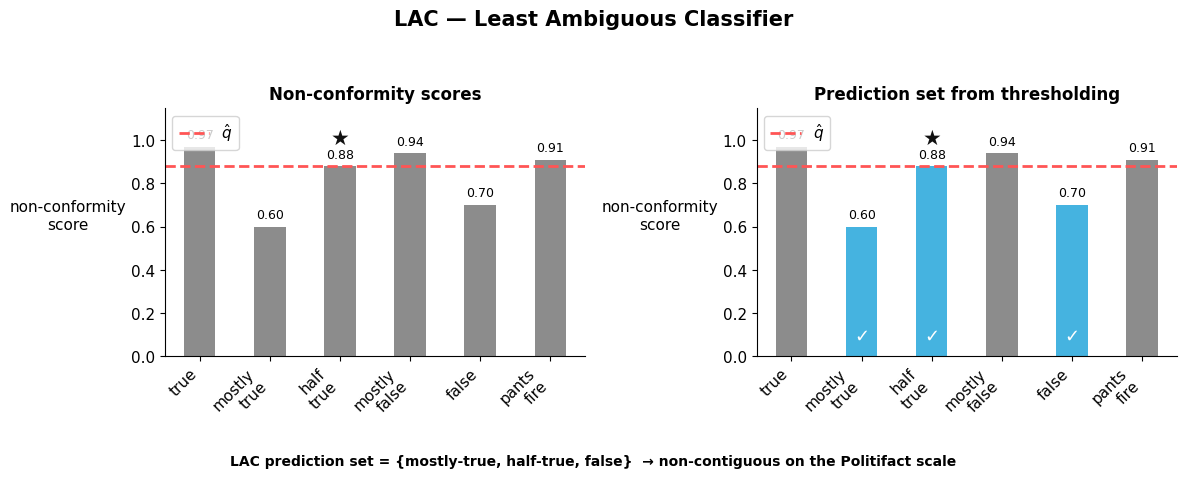


Generating APS visualization...


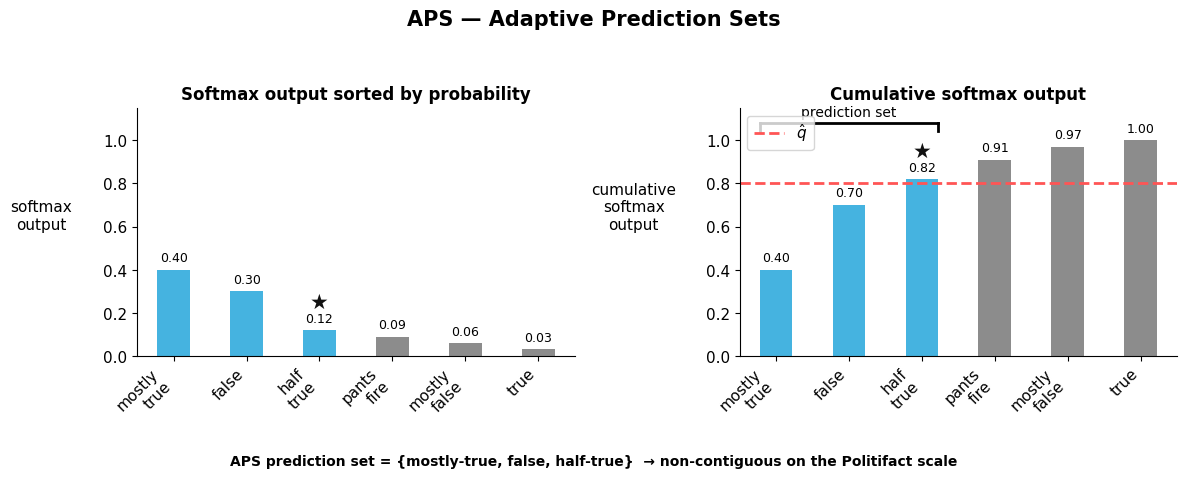


Generating Ordinal-APS visualization...


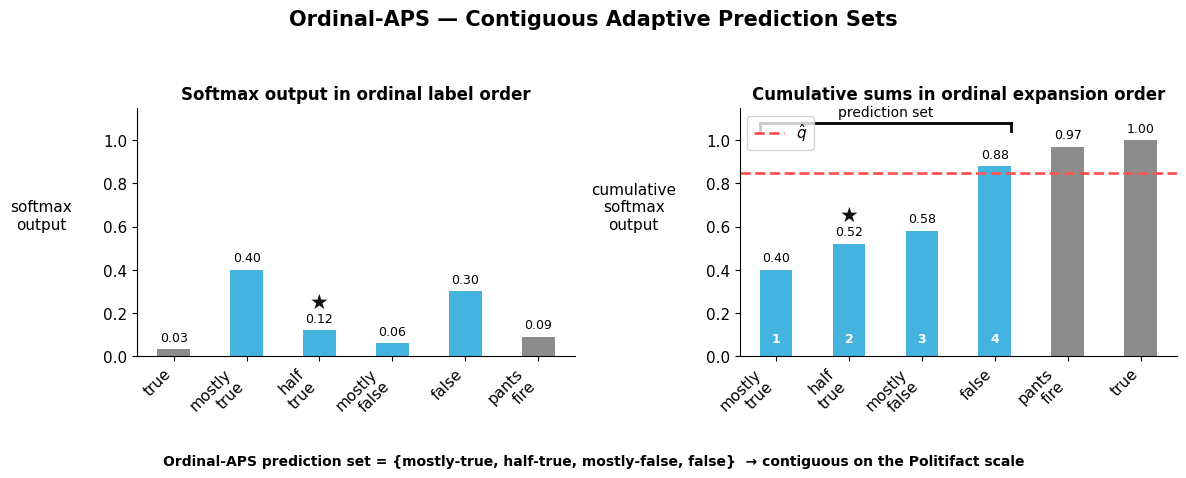

In [11]:
"""
Visual illustration of LAC, APS, and Ordinal-APS on the Politifact veracity scale.

Each method gets a two-panel figure:

LAC:
  LEFT  = LAC non-conformity scores: 1 - p(label)
  RIGHT = the same scores, preserving proportions, with selected labels highlighted

APS:
  LEFT  = softmax probabilities sorted from largest to smallest
  RIGHT = cumulative softmax sums in sorted-probability order

Ordinal-APS:
  LEFT  = softmax probabilities in ordinal Politifact order
  RIGHT = cumulative softmax sums while expanding contiguously from the argmax

The point of the example:
  - LAC and APS produce non-contiguous prediction sets.
  - Ordinal-APS produces a contiguous prediction set.
"""

import matplotlib.pyplot as plt
import numpy as np


# ---------------------------------------------------------------------------
# Example data
# ---------------------------------------------------------------------------
LABELS = [
    "true",
    "mostly\ntrue",
    "half\ntrue",
    "mostly\nfalse",
    "false",
    "pants\nfire",
]

LABELS_FLAT = [
    "true",
    "mostly-true",
    "half-true",
    "mostly-false",
    "false",
    "pants-fire",
]

# Hand-crafted probabilities.
# The true label is half-true.
#
# This setup makes LAC and APS select non-contiguous labels,
# while Ordinal-APS selects a contiguous interval.
PROBS = np.array([0.03, 0.40, 0.12, 0.06, 0.30, 0.09])

TRUE_LABEL_INDEX = 2  # half-true

# Thresholds
LAC_THRESHOLD = 0.88
APS_THRESHOLD = 0.80
ORDINAL_APS_THRESHOLD = 0.85


# ---------------------------------------------------------------------------
# Colours and style
# ---------------------------------------------------------------------------
C_SELECTED = "#45B3E0"
C_NOT_SELECTED = "#8C8C8C"
C_THRESHOLD = "#FF5555"
C_TRUE = "#111111"

BAR_WIDTH = 0.45


# ---------------------------------------------------------------------------
# General helper functions
# ---------------------------------------------------------------------------
def selected_set_string(indices):
    return "{" + ", ".join(LABELS_FLAT[i] for i in indices) + "}"


def style_axis(ax, ylim=(0, 1.15)):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_ylim(*ylim)


def draw_threshold(ax, threshold):
    ax.axhline(
        threshold,
        color=C_THRESHOLD,
        linestyle="--",
        linewidth=2,
        label=r"$\hat{q}$",
    )
    ax.legend(loc="upper left", frameon=True)


def draw_true_label_star(ax, x_position, y_position):
    ax.text(
        x_position,
        y_position,
        "★",
        ha="center",
        va="bottom",
        fontsize=15,
        color=C_TRUE,
    )


def draw_prediction_bracket(ax, start_idx, end_idx, y=1.08, label="prediction set"):
    """
    Draw a bracket above consecutive bars.

    This is appropriate for APS because the selected bars are consecutive
    in sorted-probability order, and for Ordinal-APS because they are
    consecutive in ordinal-expansion order.
    """
    x0 = start_idx - BAR_WIDTH / 2
    x1 = end_idx + BAR_WIDTH / 2

    ax.plot([x0, x1], [y, y], color="black", linewidth=2)
    ax.plot([x0, x0], [y, y - 0.035], color="black", linewidth=2)
    ax.plot([x1, x1], [y, y - 0.035], color="black", linewidth=2)

    ax.text(
        (x0 + x1) / 2,
        y + 0.02,
        label,
        ha="center",
        va="bottom",
        fontsize=10,
    )


def annotate_values(ax, bars, values, true_positions=None):
    if true_positions is None:
        true_positions = set()

    for pos, (bar, value) in enumerate(zip(bars, values)):
        x = bar.get_x() + bar.get_width() / 2
        y = bar.get_height()

        ax.text(
            x,
            y + 0.025,
            f"{value:.2f}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

        if pos in true_positions:
            draw_true_label_star(ax, x, y + 0.085)


# ---------------------------------------------------------------------------
# LAC
# ---------------------------------------------------------------------------
def plot_lac():
    """
    LAC score:

        score(label) = 1 - p(label)

    Include label if:

        score(label) <= q_hat

    Important:
        The right panel keeps the actual non-conformity-score proportions.
        It does not turn the selected labels into binary 0/1 bars.
    """
    scores = 1.0 - PROBS
    selected = scores <= LAC_THRESHOLD
    selected_indices = np.where(selected)[0]

    x = np.arange(len(LABELS))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.7))
    fig.suptitle(
        "LAC — Least Ambiguous Classifier",
        fontsize=15,
        fontweight="bold",
    )

    # -----------------------------------------------------------------------
    # LEFT: non-conformity scores
    # -----------------------------------------------------------------------
    ax = axes[0]

    bars = ax.bar(
        x,
        scores,
        width=BAR_WIDTH,
        color=C_NOT_SELECTED,
    )

    draw_threshold(ax, LAC_THRESHOLD)

    annotate_values(
        ax,
        bars,
        scores,
        true_positions={TRUE_LABEL_INDEX},
    )

    ax.set_title("Non-conformity scores", fontsize=12)
    ax.set_ylabel("non-conformity\nscore", rotation=0, labelpad=45)
    ax.set_xticks(x)
    ax.set_xticklabels(LABELS, rotation=45, ha="right")
    style_axis(ax)

    # -----------------------------------------------------------------------
    # RIGHT: selected labels, preserving non-conformity-score proportions
    # -----------------------------------------------------------------------
    ax = axes[1]

    colors = [
        C_SELECTED if selected[i] else C_NOT_SELECTED
        for i in range(len(LABELS))
    ]

    bars = ax.bar(
        x,
        scores,
        width=BAR_WIDTH,
        color=colors,
    )

    draw_threshold(ax, LAC_THRESHOLD)

    annotate_values(
        ax,
        bars,
        scores,
        true_positions={TRUE_LABEL_INDEX},
    )

    for i, bar in enumerate(bars):
        if selected[i]:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                0.05,
                "✓",
                ha="center",
                va="bottom",
                fontsize=13,
                color="white",
                fontweight="bold",
            )

    ax.set_title("Prediction set from thresholding", fontsize=12)
    ax.set_ylabel("non-conformity\nscore", rotation=0, labelpad=45)
    ax.set_xticks(x)
    ax.set_xticklabels(LABELS, rotation=45, ha="right")
    style_axis(ax)

    fig.text(
        0.5,
        0.01,
        f"LAC prediction set = {selected_set_string(selected_indices)}  "
        f"→ non-contiguous on the Politifact scale",
        ha="center",
        fontsize=10,
        fontweight="bold",
    )

    plt.tight_layout(rect=[0, 0.06, 1, 0.93])
    plt.show()


# ---------------------------------------------------------------------------
# APS
# ---------------------------------------------------------------------------
def plot_aps():
    """
    APS procedure:

        1. Sort labels by descending softmax probability.
        2. Accumulate probabilities in that sorted order.
        3. Stop when the cumulative sum reaches q_hat.

    This can produce a non-contiguous set on the ordinal label scale.
    """
    sorted_indices = np.argsort(-PROBS)
    sorted_probs = PROBS[sorted_indices]
    sorted_labels = [LABELS[i] for i in sorted_indices]

    cumulative = np.cumsum(sorted_probs)

    cutoff_position = int(np.argmax(cumulative >= APS_THRESHOLD))

    selected_positions = np.arange(len(LABELS)) <= cutoff_position
    selected_original_indices = sorted_indices[selected_positions]

    x = np.arange(len(LABELS))

    colors = [
        C_SELECTED if selected_positions[i] else C_NOT_SELECTED
        for i in range(len(LABELS))
    ]

    true_position_in_sorted_order = int(np.where(sorted_indices == TRUE_LABEL_INDEX)[0][0])

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.7))
    fig.suptitle(
        "APS — Adaptive Prediction Sets",
        fontsize=15,
        fontweight="bold",
    )

    # -----------------------------------------------------------------------
    # LEFT: sorted softmax probabilities
    # -----------------------------------------------------------------------
    ax = axes[0]

    bars = ax.bar(
        x,
        sorted_probs,
        width=BAR_WIDTH,
        color=colors,
    )

    annotate_values(
        ax,
        bars,
        sorted_probs,
        true_positions={true_position_in_sorted_order},
    )

    ax.set_title("Softmax output sorted by probability", fontsize=12)
    ax.set_ylabel("softmax\noutput", rotation=0, labelpad=45)
    ax.set_xticks(x)
    ax.set_xticklabels(sorted_labels, rotation=45, ha="right")
    style_axis(ax)

    # -----------------------------------------------------------------------
    # RIGHT: cumulative softmax sums
    # -----------------------------------------------------------------------
    ax = axes[1]

    bars = ax.bar(
        x,
        cumulative,
        width=BAR_WIDTH,
        color=colors,
    )

    draw_threshold(ax, APS_THRESHOLD)

    annotate_values(
        ax,
        bars,
        cumulative,
        true_positions={true_position_in_sorted_order},
    )

    draw_prediction_bracket(
        ax,
        start_idx=0,
        end_idx=cutoff_position,
        y=1.08,
    )

    ax.set_title("Cumulative softmax output", fontsize=12)
    ax.set_ylabel("cumulative\nsoftmax\noutput", rotation=0, labelpad=52)
    ax.set_xticks(x)
    ax.set_xticklabels(sorted_labels, rotation=45, ha="right")
    style_axis(ax)

    fig.text(
        0.5,
        0.01,
        f"APS prediction set = {selected_set_string(selected_original_indices)}  "
        f"→ non-contiguous on the Politifact scale",
        ha="center",
        fontsize=10,
        fontweight="bold",
    )

    plt.tight_layout(rect=[0, 0.06, 1, 0.93])
    plt.show()


# ---------------------------------------------------------------------------
# Ordinal-APS
# ---------------------------------------------------------------------------
def ordinal_expansion_order(probs):
    """
    Start at the argmax.

    Then expand to neighbouring labels on the ordinal scale.
    At each step, choose the neighbour with the larger probability.

    This creates an expansion order that respects the label ordering.
    """
    n = len(probs)
    start = int(np.argmax(probs))

    order = [start]

    left = start - 1
    right = start + 1

    while left >= 0 or right < n:
        if left < 0:
            chosen = right
            right += 1
        elif right >= n:
            chosen = left
            left -= 1
        elif probs[left] >= probs[right]:
            chosen = left
            left -= 1
        else:
            chosen = right
            right += 1

        order.append(chosen)

    return np.array(order)


def plot_ordinal_aps():
    """
    Ordinal-APS procedure:

        1. Start from the most probable label.
        2. Expand only to neighbouring labels.
        3. Accumulate probabilities until q_hat is reached.

    This forces the prediction set to be contiguous on the Politifact scale.
    """
    expansion_order = ordinal_expansion_order(PROBS)

    ordered_probs = PROBS[expansion_order]
    ordered_labels = [LABELS[i] for i in expansion_order]

    cumulative = np.cumsum(ordered_probs)

    cutoff_position = int(np.argmax(cumulative >= ORDINAL_APS_THRESHOLD))

    selected_positions = np.arange(len(LABELS)) <= cutoff_position
    selected_original_indices = expansion_order[selected_positions]

    selected_mask_original_order = np.zeros(len(LABELS), dtype=bool)
    selected_mask_original_order[selected_original_indices] = True

    colors_original_order = [
        C_SELECTED if selected_mask_original_order[i] else C_NOT_SELECTED
        for i in range(len(LABELS))
    ]

    colors_expansion_order = [
        C_SELECTED if selected_positions[i] else C_NOT_SELECTED
        for i in range(len(LABELS))
    ]

    true_position_in_expansion_order = int(
        np.where(expansion_order == TRUE_LABEL_INDEX)[0][0]
    )

    x = np.arange(len(LABELS))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.7))
    fig.suptitle(
        "Ordinal-APS — Contiguous Adaptive Prediction Sets",
        fontsize=15,
        fontweight="bold",
    )

    # -----------------------------------------------------------------------
    # LEFT: softmax output in original ordinal label order
    # -----------------------------------------------------------------------
    ax = axes[0]

    bars = ax.bar(
        x,
        PROBS,
        width=BAR_WIDTH,
        color=colors_original_order,
    )

    annotate_values(
        ax,
        bars,
        PROBS,
        true_positions={TRUE_LABEL_INDEX},
    )

    ax.set_title("Softmax output in ordinal label order", fontsize=12)
    ax.set_ylabel("softmax\noutput", rotation=0, labelpad=45)
    ax.set_xticks(x)
    ax.set_xticklabels(LABELS, rotation=45, ha="right")
    style_axis(ax)

    # -----------------------------------------------------------------------
    # RIGHT: cumulative sums in ordinal expansion order
    # -----------------------------------------------------------------------
    ax = axes[1]

    bars = ax.bar(
        x,
        cumulative,
        width=BAR_WIDTH,
        color=colors_expansion_order,
    )

    draw_threshold(ax, ORDINAL_APS_THRESHOLD)

    annotate_values(
        ax,
        bars,
        cumulative,
        true_positions={true_position_in_expansion_order},
    )

    for pos, bar in enumerate(bars):
        if selected_positions[pos]:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                0.05,
                str(pos + 1),
                ha="center",
                va="bottom",
                fontsize=9,
                color="white",
                fontweight="bold",
            )

    draw_prediction_bracket(
        ax,
        start_idx=0,
        end_idx=cutoff_position,
        y=1.08,
    )

    ax.set_title("Cumulative sums in ordinal expansion order", fontsize=12)
    ax.set_ylabel("cumulative\nsoftmax\noutput", rotation=0, labelpad=52)
    ax.set_xticks(x)
    ax.set_xticklabels(ordered_labels, rotation=45, ha="right")
    style_axis(ax)

    # Sort selected labels back into Politifact order for the caption
    selected_original_indices_sorted = np.sort(selected_original_indices)

    fig.text(
        0.5,
        0.01,
        f"Ordinal-APS prediction set = "
        f"{selected_set_string(selected_original_indices_sorted)}  "
        f"→ contiguous on the Politifact scale",
        ha="center",
        fontsize=10,
        fontweight="bold",
    )

    plt.tight_layout(rect=[0, 0.06, 1, 0.93])
    plt.show()


# ---------------------------------------------------------------------------
# Main
# ---------------------------------------------------------------------------
if __name__ == "__main__":
    print("Softmax probabilities:")
    for i, (label, prob) in enumerate(zip(LABELS_FLAT, PROBS)):
        marker = "  <-- true label" if i == TRUE_LABEL_INDEX else ""
        print(f"{label:13s}: {prob:.2f}{marker}")

    print("\nGenerating LAC visualization...")
    plot_lac()

    print("\nGenerating APS visualization...")
    plot_aps()

    print("\nGenerating Ordinal-APS visualization...")
    plot_ordinal_aps()